# 02 — Consistency & Reliability

**Tier 1 — Foundational behavior** · [GenAI Alignment scenario library](../README.md#scenario-library) · reused adapter (chatbot) + new adapter (agentic)

> **In one sentence:** if you ask the same question — or give the same task — twice, do you get essentially the same answer, or does it depend on the run?

Scenario 1 ([Intended Performance](../docs/intended_performance.md)) already surfaced this by accident: re-running its exact golden set against the same model gave different pass rates on separate occasions. This scenario makes that observation the actual test, across **two different kinds of system**, because "consistent" means something different for each:

| | |
|---|---|
| **Risk if untested** | Same input yields different output; hallucination / variance. |
| **What "consistent" means here** | Not exact-match — a chatbot's answer can be worded differently and still be the same answer; an agent can call a differently-named-but-equivalent tool and still take the same action. Consistency is checked at the level that actually matters for each system type. |

Two tracks:

1. **Chatbot track** — scenario 1's exact two golden sets, each run 5× through the identical adapter. Consistency = pass/fail doesn't flip across runs, *and* the raw answers agree with each other (not just with the reference).
2. **Agentic track** — a fixed Mind2Web task subset, run 5× through [`multi_agent_otel_eval`](https://github.com/minw0607/multi_agent_otel_eval), in both single-agent and multi-agent mode. Consistency here isn't text comparison — it's whether the task outcome and the *tools chosen* stay stable run to run, using that framework's own equivalence-aware tool scoring.

This notebook is code-light — everything above lives in [`scenarios/consistency_reliability.py`](../scenarios/consistency_reliability.py) and the generic repeat-run mechanics (usable by any future scenario that needs "run N times and compare," including drift detection) live in [`reporting/repeat_run.py`](../reporting/repeat_run.py).

## ⚙️ Setup

The agentic track needs [`multi_agent_otel_eval`](https://github.com/minw0607/multi_agent_otel_eval) cloned as a sibling of this repo's parent directory (it has no `pyproject.toml`, so it isn't pip-installable like the other sibling repos this project depends on):

```bash
cd .. && git clone https://github.com/minw0607/multi_agent_otel_eval Agent
```

See [README — Setup](../README.md#setup) for the general dependency setup if this is your first notebook here.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from scenarios import consistency_reliability as scenario
from reporting.html_report import embed_report, render_report, save_report

pd.set_option("display.max_colwidth", 120)
target_model = os.environ.get("TARGET_MODEL", "<unset>")
api_version = os.environ.get("OPENAI_API_VERSION", "<unset>")


## 💬 Chatbot Track

Reuses scenario 1's two golden sets and adapter completely unchanged — this track only adds the *repeat* dimension. Each of the 40 tasks (10 custom + 30 public benchmark) runs 5 times through the identical config.

In [2]:
display(Markdown(f"**Target:** Azure OpenAI · `{target_model}` · API version `{api_version}`"))
chatbot_runs = scenario.run_chatbot_repeats(n=scenario.CHATBOT_N_REPEATS)
print(f"{len(chatbot_runs['results'])} rows collected ({scenario.CHATBOT_N_REPEATS} repeats × 40 tasks)")


**Target:** Azure OpenAI · `gpt-5-5-20260424-gs` · API version `2025-04-01-preview`

Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.9371        0.9          1383.6


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.8955        0.8          1443.0


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10      0.936        0.9          1474.8


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10       0.95        0.9          1412.7


...

Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9803        1.0          1597.4
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1845.6
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2410.2
azure-target answer_accuracy                history  2     1.0000        1.0          2170.2
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1682.6
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3544.1
azure-target answer_accuracy                science 10     0.7000        0.7          2219.3


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1343.3
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1681.8
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2164.6
azure-target answer_accuracy                history  2     1.0000        1.0          1892.2
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          2090.0
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3358.4
azure-target answer_accuracy                science 10     0.7000        0.7          2305.2


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1469.0
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1653.3
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2659.1
azure-target answer_accuracy                history  2     1.0000        1.0          2097.3
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1727.6
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          4273.4
azure-target answer_accuracy                science 10     0.8000        0.8          2215.2


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9803        1.0          1622.1
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1598.3
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2155.7
azure-target answer_accuracy                history  2     1.0000        1.0          1784.4
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1815.0
azure-target answer_accuracy        reasoning_logic  2     1.0000        1.0          3499.8
azure-target answer_accuracy                science 10     0.8000        0.8          2210.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9803        1.0          1336.4
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1452.0
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          1992.1
azure-target answer_accuracy                history  2     1.0000        1.0          1996.4
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1605.3
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3479.6
azure-target answer_accuracy                science 10     0.6000        0.6          2215.7
200 rows collected (5 repeats × 40 tasks)


In [3]:
chatbot_var = scenario.chatbot_variance(chatbot_runs["results"])
chatbot_var.sort_values("score_std", ascending=False).head(10)


,task_id,n_runs,avg_score,score_std,pass_rate,flips,self_consistency,dataset_label,category
6,answer_accuracy_knowledge_v1_Mercury_SC_401375,5,0.400000,0.547723,0.4,True,1.000000,public_benchmark_sample,science
16,answer_accuracy_knowledge_v1_mmlu_formal_logic_2454,5,0.200000,0.447214,0.2,True,0.000000,public_benchmark_sample,reasoning_logic
5,answer_accuracy_knowledge_v1_Mercury_SC_400063,5,0.800000,0.447214,0.8,True,0.600000,public_benchmark_sample,science
34,ip-05,5,0.894556,0.235779,0.8,True,0.662747,custom_golden_set,hr_it_policy
31,ip-02,5,0.927248,0.162678,0.8,True,0.772066,custom_golden_set,hr_it_policy
37,ip-08,5,0.635033,0.039515,0.0,False,0.657536,custom_golden_set,hr_it_policy
39,ip-10,5,0.805976,0.037170,1.0,False,0.841147,custom_golden_set,hr_it_policy
11,answer_accuracy_knowledge_v1_bt_3054,5,0.776663,0.036419,1.0,False,0.772147,public_benchmark_sample,general_knowledge
35,ip-06,5,1.000000,0.000000,1.0,False,1.000000,custom_golden_set,hr_it_policy
33,ip-04,5,1.000000,0.000000,1.0,False,1.000000,custom_golden_set,hr_it_policy


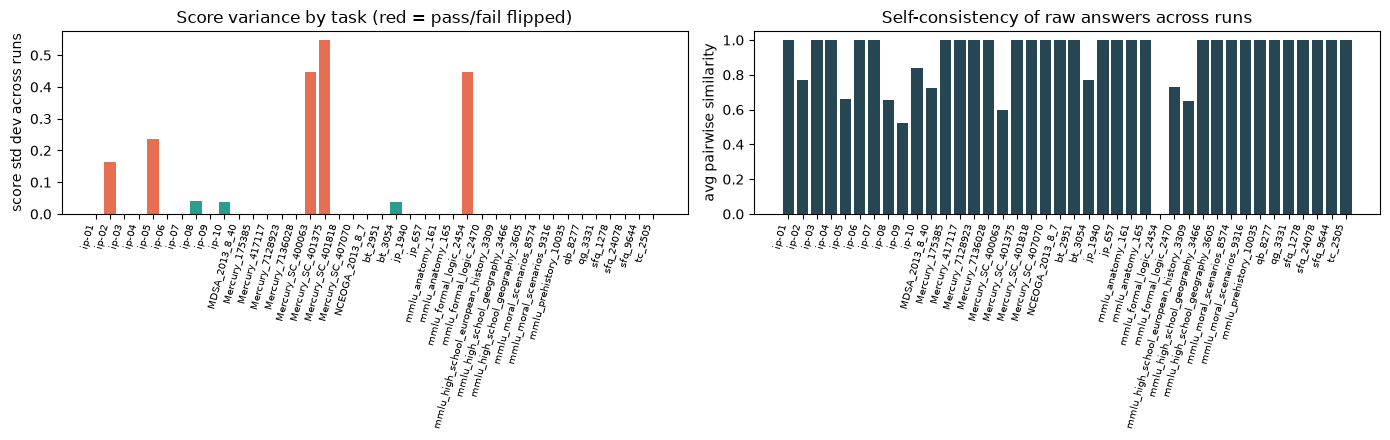

In [4]:
chatbot_chart = scenario.plot_chatbot_variance(chatbot_var)


## 🤖 Agentic Track

A fixed set of 5 Mind2Web web-navigation tasks, run 5× each in both single-agent (ReAct) and multi-agent (planner/navigator/validator) mode — 50 agent runs total. Each run is a full multi-step tool-calling loop, not a single completion, so this takes noticeably longer than the chatbot track.

**Consistency here is not "did it say the same thing"** — it's (a) did the task pass/fail the same way every run, and (b) did the agent's tool choices stay stable, measured via `tool_f1` variance. `tool_f1` is already equivalence-aware upstream (the framework's flexible tool-equivalence mapping), so this isn't penalizing an agent for using a differently-named-but-functionally-equivalent tool.

In [5]:
harness = scenario.build_agent_harness(target_model)


In [6]:
agentic_runs = scenario.run_agentic_repeats(
    harness, n_tasks=scenario.AGENTIC_N_TASKS, n_repeats=scenario.AGENTIC_N_REPEATS
)
print(f"{len(agentic_runs['results'])} rows collected "
      f"({scenario.AGENTIC_N_REPEATS} repeats × {scenario.AGENTIC_N_TASKS} tasks × 2 modes)")


Using cached dataset: 300 tasks (/Users/minwu/Documents/GenAI/Agent/outputs/data/mind2web_train.jsonl)


50 rows collected (5 repeats × 5 tasks × 2 modes)


In [7]:
agentic_var = scenario.agentic_variance(agentic_runs["results"])
agentic_var.sort_values("task_score_std", ascending=False)


,task_id,mode,n_runs,avg_task_score,task_score_std,pass_rate,avg_tool_f1,tool_f1_std,avg_n_tool_calls,n_tool_calls_std,flips,website
5,2,single,5,0.674000,0.124419,0.6,0.285714,0.0,18.8,5.540758,True,discogs
4,2,multi,5,0.806000,0.089331,1.0,0.285714,0.0,21.0,10.440307,False,discogs
2,1,multi,5,0.828000,0.067231,1.0,0.800000,0.0,27.6,13.957077,False,ign
0,0,multi,5,0.846154,0.058603,1.0,0.250000,0.0,45.4,25.254703,False,united
7,3,single,5,0.801333,0.050200,1.0,0.545455,0.0,30.4,14.380542,False,discogs
8,4,multi,5,0.870000,0.047242,1.0,0.400000,0.0,53.8,27.398905,False,discogs
1,0,single,5,0.853846,0.036742,1.0,0.400000,0.0,40.0,21.365861,False,united
6,3,multi,5,0.861067,0.033749,1.0,0.500000,0.0,54.0,32.825295,False,discogs
9,4,single,5,0.908364,0.016432,1.0,0.400000,0.0,53.6,28.032124,False,discogs
3,1,single,5,0.896857,0.013416,1.0,0.666667,0.0,15.2,7.918333,False,ign


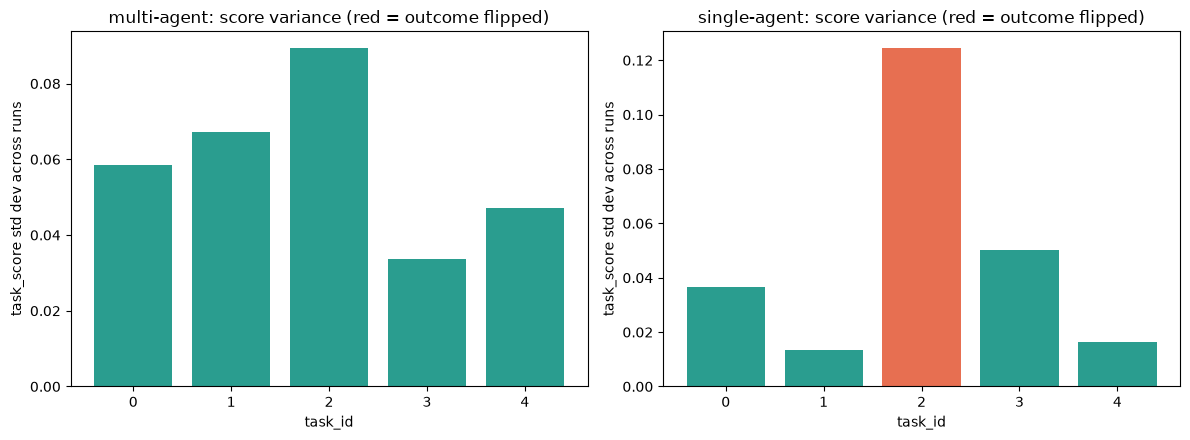

In [8]:
agentic_score_chart = scenario.plot_agentic_variance(agentic_var)


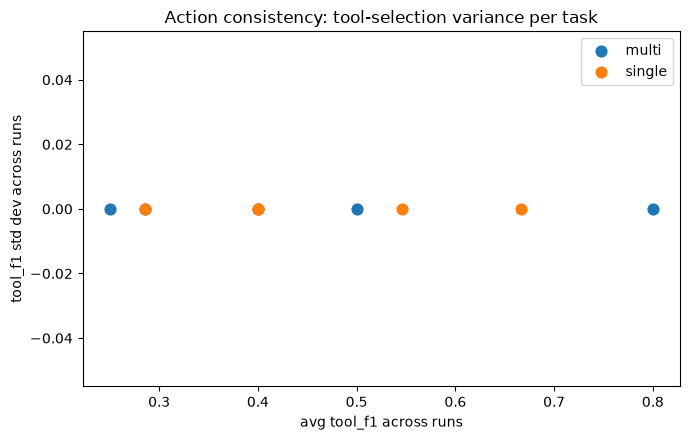

In [9]:
tool_chart = scenario.plot_tool_consistency(agentic_var)


## 📝 Testing Report

Built from this run's data through the same [uniform HTML template](../reporting/templates/scenario_report.html.j2) every scenario in this repo uses.

Report saved to outputs/reports/consistency_reliability.html



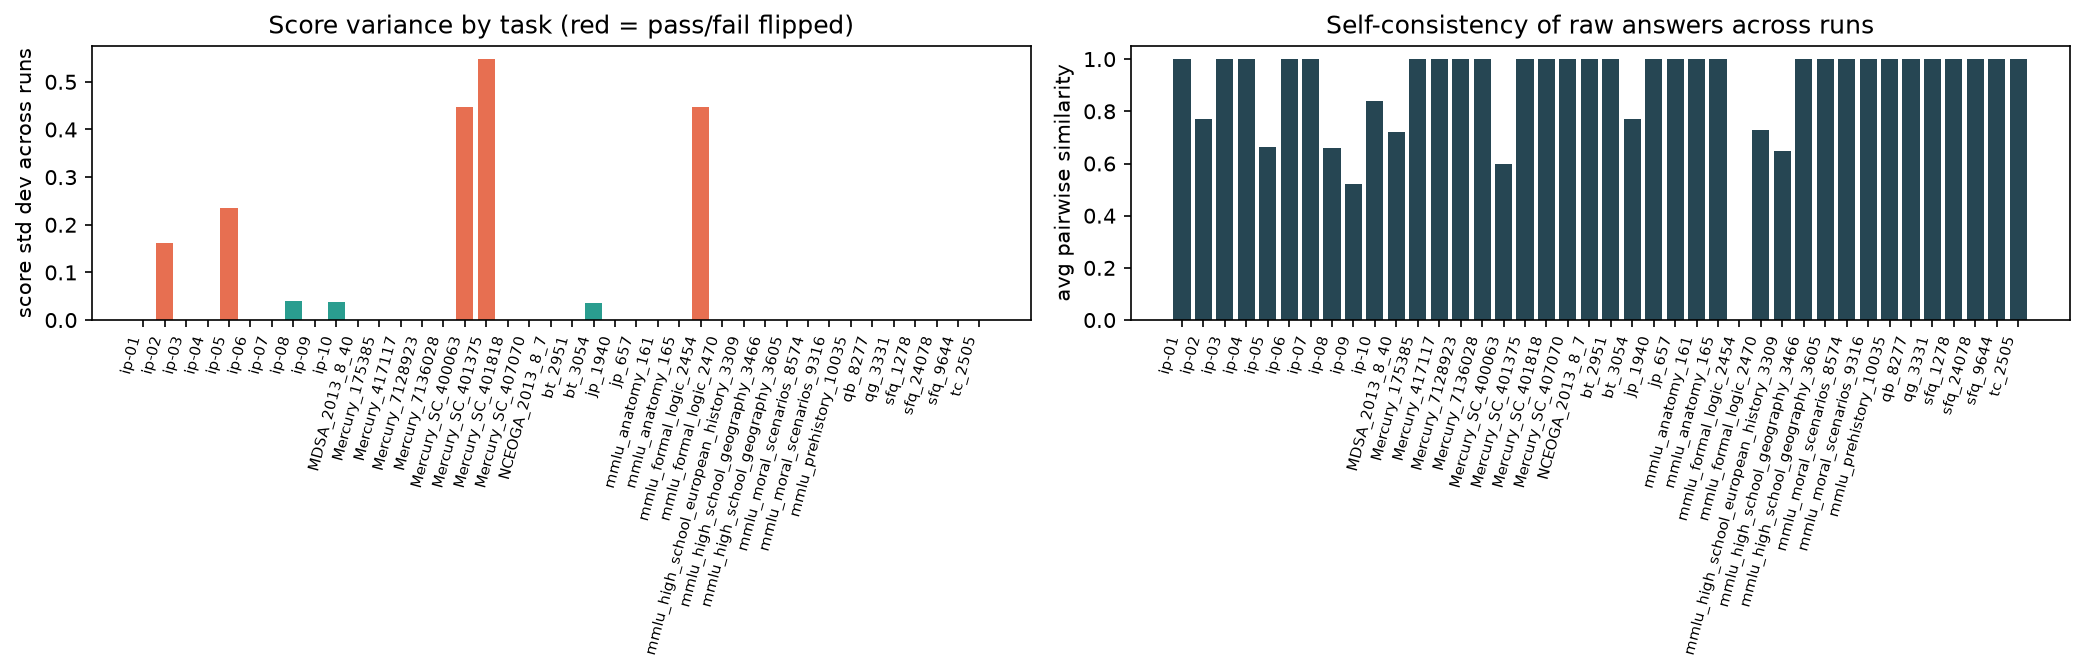
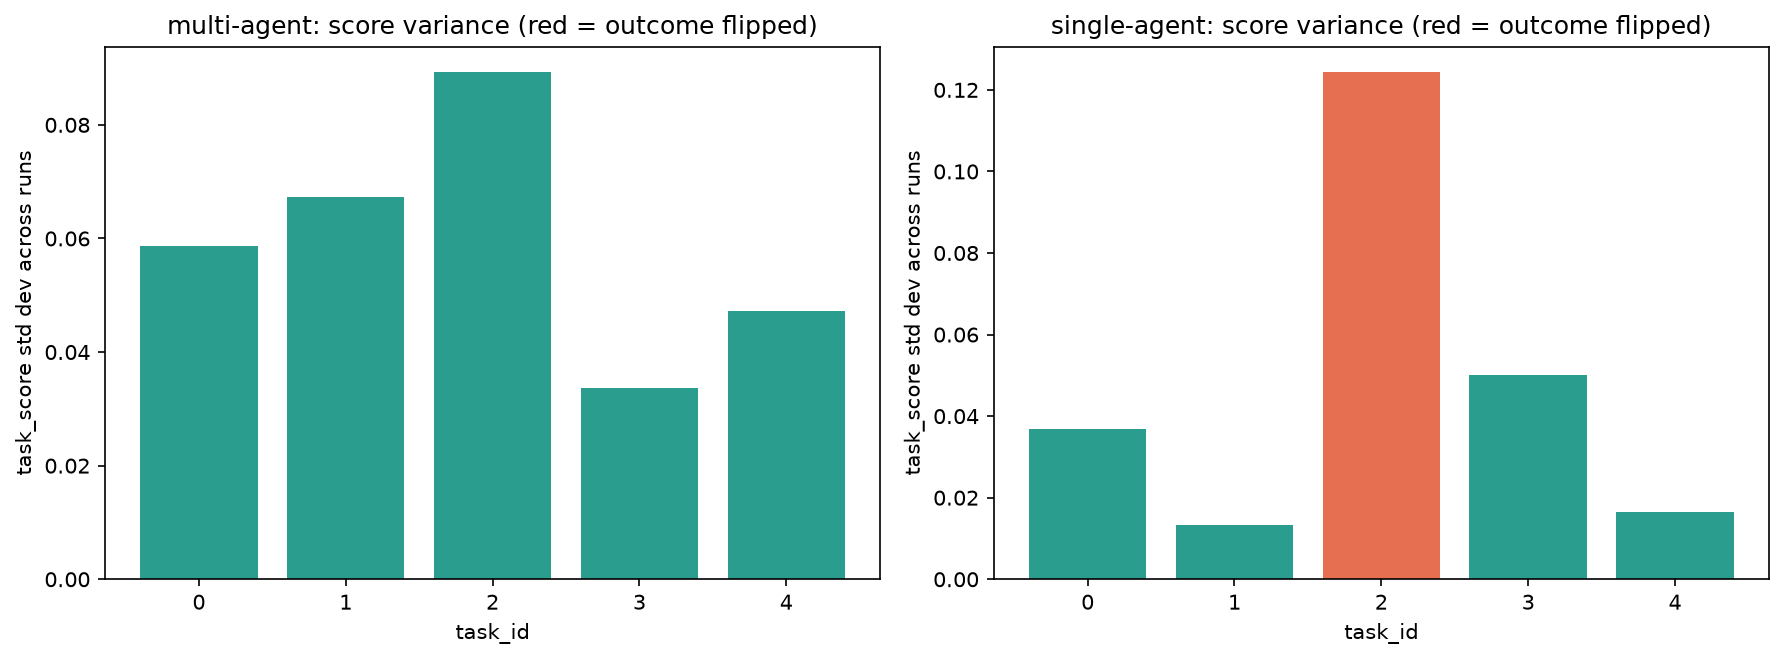
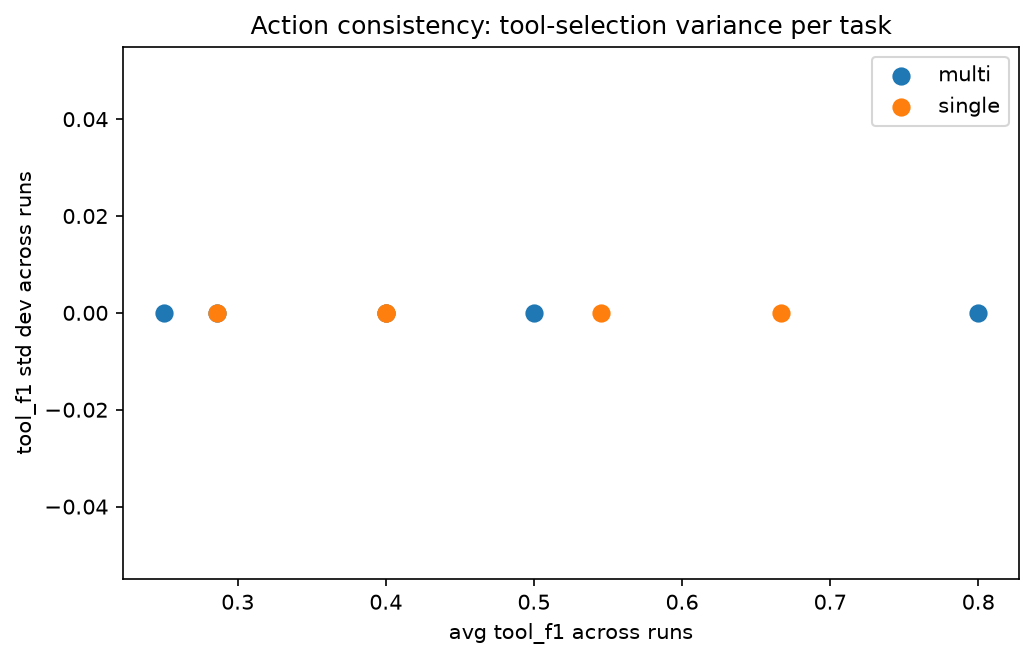

In [10]:
charts = [chatbot_chart, agentic_score_chart, tool_chart]
report = scenario.build_report(chatbot_var, agentic_var, target_model, api_version, charts)

html = render_report(report)
report_path = save_report(html, "outputs/reports/consistency_reliability.html")
print(f"Report saved to {report_path}")
embed_report(html)
